In [1]:
# The following code will only execute
# successfully when compression is complete

import kagglehub

# Download latest version
path = kagglehub.dataset_download("ajeetkumar20/cicids-2017")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/ajeetkumar20/cicids-2017


Starting data loading...
Data loaded successfully. Total rows: 2830743, Total columns: 79
Cleaning data...
Preparing labels and features...
Training the Decision Tree model (this might take a minute)...
Making predictions on the test set...

=== Model Performance ===
Accuracy:  0.9988
Precision: 0.9968
Recall:    0.9968
F1-score:  0.9968


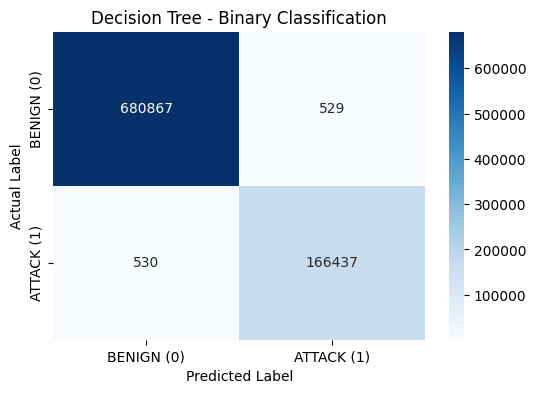

In [2]:
import pandas as pd
import numpy as np
import os
import glob
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Starting data loading...")

# 1. Locate all CSV files in the dataset directory
dataset_path = '/kaggle/input/datasets/ajeetkumar20/cicids-2017'
csv_files = glob.glob(os.path.join(dataset_path, "**/*.csv"), recursive=True)

# 2. Combine all daily CSVs into one massive DataFrame
df_list = [pd.read_csv(file) for file in csv_files]
df = pd.concat(df_list, ignore_index=True)
print(f"Data loaded successfully. Total rows: {df.shape[0]}, Total columns: {df.shape[1]}")

# 3. Data Cleaning
print("Cleaning data...")
# Remove leading/trailing whitespaces from column names (a known issue in CICIDS2017)
df.columns = df.columns.str.strip()

# Replace Infinity values with NaN, then drop any rows with NaN values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

# 4. Label Engineering (Binary Classification)
# The paper tests Binary classification: BENIGN vs ATTACK
print("Preparing labels and features...")
# Convert 'BENIGN' to 0, and any other attack type to 1
df['Label'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

# Separate features (X) and target (y)
X = df.drop(columns=['Label'])
y = df['Label']

# 5. Train-Test Split
# Splitting the data: 70% for training, 30% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# 6. Train the Decision Tree Model
print("Training the Decision Tree model (this might take a minute)...")
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

# 7. Make Predictions
print("Making predictions on the test set...")
y_pred = dt_classifier.predict(X_test)

# 8. Evaluate the Model (Matching the paper's metrics)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n=== Model Performance ===")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

# 9. Plot the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['BENIGN (0)', 'ATTACK (1)'], 
            yticklabels=['BENIGN (0)', 'ATTACK (1)'])
plt.title('Decision Tree - Binary Classification')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()